## Model Selection

Before we move on we would like to choose the best possible model for each of the two cases: daily forecast and hourly forecast. It seems that for the daily forecast in the long term you choose linear_order2 in the short to medium term potentially hybrid_order2. For the hourly forecast it seems that just using XGBoost is the best possible model.

The main question is that in the daily forecast if we were to optimise the hyperparameters of the XGBoost model within the hybrid model would it make hybrid_order2 better than linear_order2 in both the short and long term. It would also be nice to do hyperparamter optimisation for the hourly forecast as well just to see whether we can improve the predictions or not. 

Finally it would be good to look at SHAP values to see if we can drop any of the features, particualarly some of the lags as they can make the models computationally expensive.

For our own use (maybe delete later): http://kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

https://hyperopt.github.io/hyperopt/?source=post_page

https://github.com/hyperopt/hyperopt/wiki/FMin

In [6]:
from hyperopt import hp, fmin, tpe, hp, Trials
from hyperopt.pyll import scope
from jfk_taxis import load_design, load_config, load_models, load_lags, create_val_data, wrapped_objective, save_hyperparams, load_hyperparams, save_obj, load_obj, split_params, test_hyperparams, load_ts_data, split_test_train_sets, load_process_lags
from sklearn.linear_model import LinearRegression
import numpy as np

In [7]:
# Load config and project root
config, PROJECT_ROOT = load_config()


In [8]:
# First load the significant lags
daily_lags, used_hourly_lags = load_process_lags()

In [9]:
# Load ts data
ts_daily, ts_hourly = load_ts_data()

In [10]:
# Create test train sets as defined in config.yml
ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test = split_test_train_sets(ts_daily, ts_hourly)

In [6]:
# Define search space
space = {
    # We rely on early stopping when fitting so this isn't an optimised value
    # number of trees
    "n_estimators": 500,

    # Learning rate
    # step size shrinkage, smaller = slower but more precise learning
    "learning_rate": 0.05,

    # Depth/complexity
    # Max depth of tree, larger more complex trees but can cause overfitting
    "max_depth": scope.int(hp.quniform("max_depth", 3, 6, 1)), # scope.int ensures we take ints only
    # minimum "weight" needed in child node. Higher values more conservative, fewer splits helps prevent overfitting
    "min_child_weight": hp.loguniform("min_child_weight", -2.3, 2.3), # approx [0.1, 10]

    # Randomisation/feature subsampling
    # fraction of rows used per tree, lower adds randomness reduces overfitting
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    # fraction of features used per tree
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),

    # Regularisation
    # L2 penalty, good range is [0.1, 10] we use loguniform because this means that every order of magnitude has equal probability, the def of log uniform in hyperopt is that it returns a value exp(U(low,high)) where U is uniform dist.  
    "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-2), np.log(100)), # [0.01, 100]
    # L1 penalty
    "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-3), np.log(10)), # [0.001, 10]

    # Split pnealty (gamma) 
    # minimum loss reduction required to split a node, higher values = more conservative
    "gamma": hp.loguniform("gamma", -7.0, 2.3), # approx [0.0009, 10]

    "random_state": 37,
    #"early_stopping_rounds": 100,
    "eval_metric": "mae", 
    "tree_method": "hist",
    "device": "cuda" # Use GPU if available
}
    
    

There are a few interesting things we would like to vary when doing our Bayesian hyperparamter optimisation. The first is that we want to both include and exclude COVID from the data we use to tune hyperparamters on.

The reason for this is because during COVID the usual seasonality breaks down dramatically as we get unusal travel patterns. So it may be worth tuning a model on data without COVID as then it is being asseseed more on its ability to pick up the more "normal" patterns within the data. You then have a question of do you use pre or post COVID data, there is more pre COVID data but it will obviously be less relevant for forecasting in the present. Alternatively it may be actually be worth including the COVID data as then the model is tuned to be more robust to "unusal" regimines within the data.

So as it's not clear which of the three will be optimal we will just run all three and then compare the models that hyperopt finds.

For the daily series we wil use a 30 day forecast in our objection function to validate with. For the hourly series we will do a weekly forecast (168 hours).

In [7]:
# Dictionary of parameters for Baysian optimisation
bayes_dict = {}

In [8]:
# Daily non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = daily_lags
constant = False
order = 0
fourier_features = config["modelling"]["daily_fourier_features"]
time_step = "D"
hybrid = None
steps = config["hyperparameter_tuning"]["daily_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_non_linear_incl_COVID": ts_daily_train,
    #"daily_non_linear_post_COVID": ts_daily_train["2022-01-01":] TODO decide if we want to do this, there are problems with the folds being too small
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }

In [9]:
# Daily non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = daily_lags
constant = True
order = 2 # we use 2nd order as this performed the best in the purely linear case, the hybrid model is just a boosted version of the purely linear case so we expect order 2 to perform the best
fourier_features = config["modelling"]["daily_fourier_features"]
time_step = "D"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["daily_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_hybrid_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_hybrid_non_linear_incl_COVID": ts_daily_train,
    #"daily_hybrid_non_linear_post_COVID": ts_daily_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }

In [10]:
# Hourly non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = used_hourly_lags
constant = False
order = 0
fourier_features = config["modelling"]["hourly_fourier_features"]
time_step = "h"
hybrid = None
steps = config["hyperparameter_tuning"]["hourly_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_non_linear_incl_COVID": ts_hourly_train,
    #"hourly_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }


In [11]:
# Hourly non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = used_hourly_lags
constant = True
order = 2 # we use 2nd order as this performed the best in the purely linear case, the hybrid model is just a boosted version of the purely linear case so we expect order 2 to perform the best
fourier_features = config["modelling"]["hourly_fourier_features"]
time_step = "h"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["hourly_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_hybrid_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_hybrid_non_linear_incl_COVID": ts_hourly_train,
    #"hourly_hybrid_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }


In [12]:
# Loop through the Bayes dict, create the folds and run fmin for 100 evals to optimise hyperparamters, save the hyperparameters and sigs to a .pkl object

# list to store the keys
sig_list = []

for key, value in bayes_dict.items():
    print(f"Running hyperparameter optimisation for {key}")
    
    # Create the folds
    fold_dict = create_val_data(value["n_splits"], value["test_size"], value["lags"], value["constant"], value["order"], value["fourier_features"], value["time_step"], value["ts"])

    # Set attributes of wrapped_objective
    wrapped_objective.fold_dict = fold_dict
    wrapped_objective.lags = value["lags"]
    wrapped_objective.steps = value["steps"]
    wrapped_objective.hybrid = value["hybrid"]

    # Optimisation algorithm
    trials = Trials()

    best_hyperparams = fmin(fn = wrapped_objective,
                            space = space,
                            algo = tpe.suggest,
                            max_evals = config["hyperparameter_tuning"]["max_evals"],
                            trials = trials)

    # Log hyperparams 
    print("The best hyperparamters are: ", "\n")
    print(best_hyperparams)

    # Before we save the hyperparams we need to change the type of max_alpha to int 
    # as well as add some of the parameters that aren't in best_hyperparmas, n_estimators, learnining_rate, random_state, eval_metric, tree_method and device
    # At the same time we may as well convert the remaining hyperparams to floats rather than np.float64 
    for key2, value2 in best_hyperparams.items():
        if key2 != "max_depth":
            best_hyperparams[key2] = float(value2)
        else:
            best_hyperparams[key2] = int(value2)

    best_hyperparams["n_estimators"] = space["n_estimators"]
    best_hyperparams["learning_rate"] = space["learning_rate"]
    best_hyperparams["random_state"] = space["random_state"]
    best_hyperparams["eval_metric"] = space["eval_metric"]
    best_hyperparams["tree_method"] = space["tree_method"]
    best_hyperparams["device"] = space["device"]

    # Save hyperparams
    save_hyperparams(best_hyperparams, key)

    # Append the sig to the list
    sig_list.append(key)

# Save signatures
save_obj(sig_list, "hyperparam_sigs")

Running hyperparameter optimisation for daily_non_linear_pre_COVID
Fold 0
[   0    1    2 ... 3165 3166 3167]
Fold 1
[   0    1    2 ... 3195 3196 3197]
Fold 2
[   0    1    2 ... 3225 3226 3227]
Fold 3
[   0    1    2 ... 3255 3256 3257]
  0%|          | 0/3 [00:00<?, ?trial/s, best loss=?]

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\xgboost\core.py:705: UserWarning: [14:02:30] WARNING: D:\bld\xgboost-split_1755048447205\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Fit time: 4.58 seconds                               
Predict time: 0.2295 seconds                         
Fit time: 4.43 seconds                               
Predict time: 0.2180 seconds                         
Fit time: 4.36 seconds                               
Predict time: 0.2200 seconds                         
Fit time: 4.42 seconds                               
Predict time: 0.2200 seconds                         
MAEs:                                                
[504.64226888020835, 433.09192708333336, 892.330322265625, 795.218359375]
Avg MAE:                                             
656.3207194010416                                    
Fit time: 4.80 seconds                                                        
Predict time: 0.2315 seconds                                                  
Fit time: 4.67 seconds                                                        
Predict time: 0.2200 seconds                                                  
Fit time: 4.81 s

In [11]:
# Load signatures
hyper_sig = load_obj("hyperparam_sigs")

# Dict of hyperparams
hyper_dict = {}

# Load the hyperparams for each model
for sig in hyper_sig:
    hyper_params = load_hyperparams(sig)
    hyper_dict[sig] = hyper_params


In [12]:
# The first interesting thing to compare would be how do the models tuned on pre, incl and post COVID compare to each other as well as to the previous best model from the modelling notebook
# to make this easier we will split up into four dicts, daily non-linear, daily hybrid, hourly non-linear, hourly hybrid

daily_non_linear_dict = {}
daily_hybrid_dict = {}
hourly_non_linear_dict = {}
hourly_hybrid_dict = {}

# Split into the four dicts
daily_non_linear_dict, daily_hybrid_dict, hourly_non_linear_dict, hourly_hybrid_dict = split_params(hyper_dict)


# Create dict of these dicts to pass to test_hyperparams
dict_full = {
    config["hyperparameter_tuning"]["daily_linear_key"]: daily_non_linear_dict, 
    config["hyperparameter_tuning"]["daily_hybrid_key"]: daily_hybrid_dict, 
    config["hyperparameter_tuning"]["hourly_linear_key"]: hourly_non_linear_dict, 
    config["hyperparameter_tuning"]["hourly_hybrid_key"]: hourly_hybrid_dict
    }

In [13]:
# We are now going to forecast all of the models inside these four categories (daily, daily_hybrid, hourly, hourly_hybrid)
# at first just within the categories compared to the best model from the modelling notebook
# So for daily that would be linear_order_2, but also the non linear base model and the naive base for comparison

In [14]:
# Set up parameters for test_hyperparams
daily_lags = daily_lags
used_hourly_lags = used_hourly_lags
ts_daily_train = ts_daily_train
ts_daily_test = ts_daily_test
ts_hourly_train = ts_hourly_train
ts_hourly_test = ts_hourly_test
daily_steps = config["hyperparameter_tuning"]["daily_steps"]
hourly_steps = config["hyperparameter_tuning"]["hourly_steps"]

MAE Linear: 460.29 for step = 30, model = linear_order2


c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\xgboost\core.py:705: UserWarning: [14:24:08] WARNING: D:\bld\xgboost-split_1755048447205\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


MAE Non Linear: 603.34 for step = 30, model = base_non_linear
MAE Non Linear: 623.27 for step = 30, model = daily_non_linear_pre_COVID
Naive MAE: MAE = 545.37



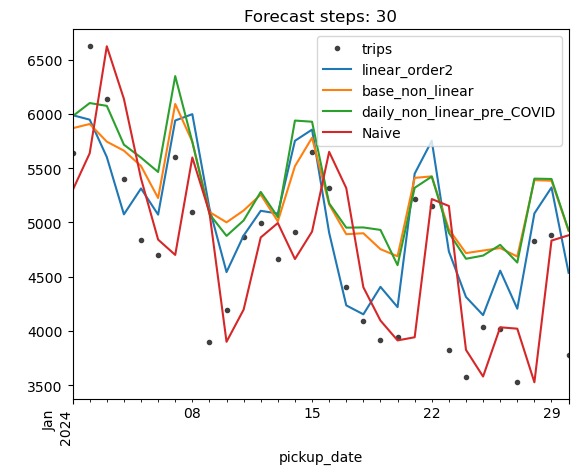

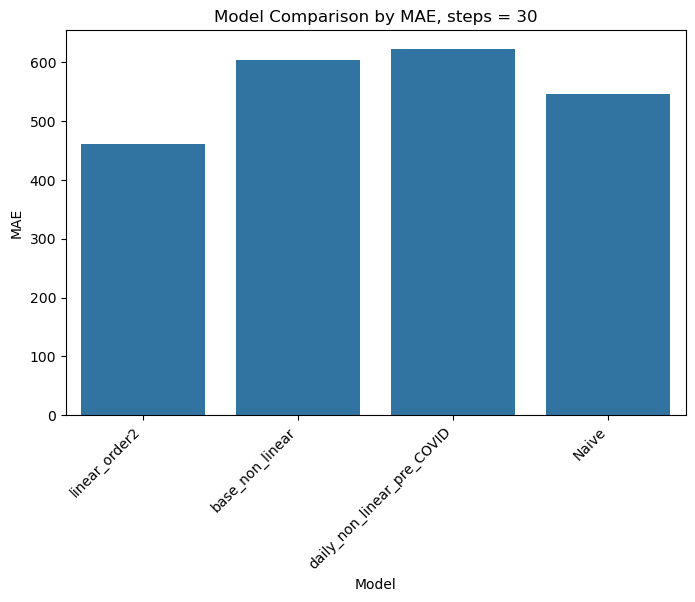

MAE Linear: 460.29 for step = 30, model = linear_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
MAE Non Linear: 549.02 for step = 30, model = daily_non_linear_incl_COVID
Naive MAE: MAE = 545.37



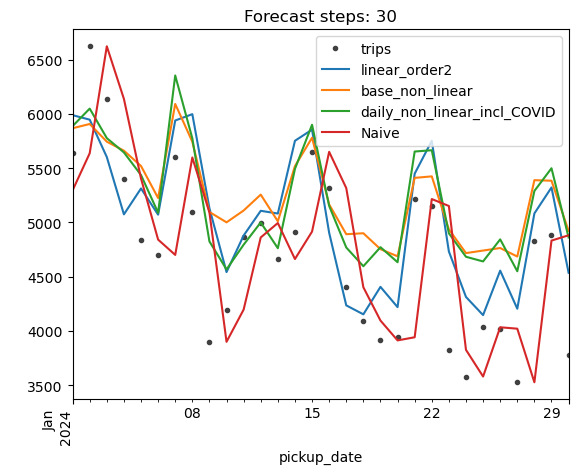

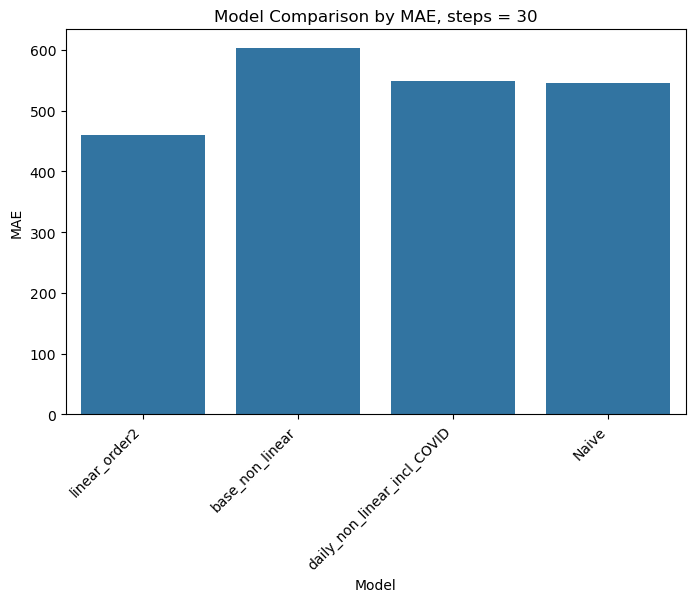

MAE Linear: 341.65 for step = 30, model = hybrid_order1
MAE Linear: 313.32 for step = 30, model = hybrid_order2
MAE Linear: 411.75 for step = 30, model = daily_hybrid_non_linear_pre_COVID_hybrid_order1
MAE Linear: 362.62 for step = 30, model = daily_hybrid_non_linear_pre_COVID_hybrid_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
Naive MAE: MAE = 545.37



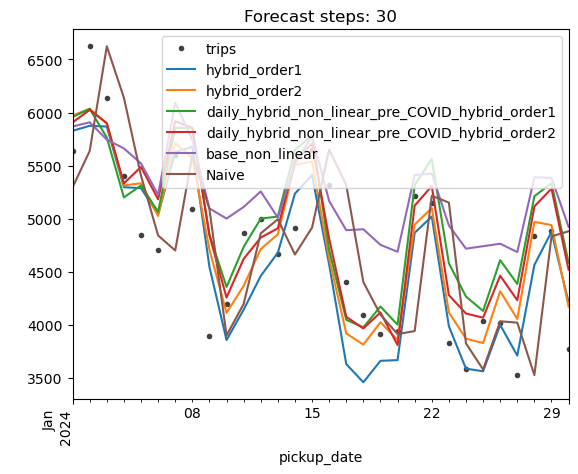

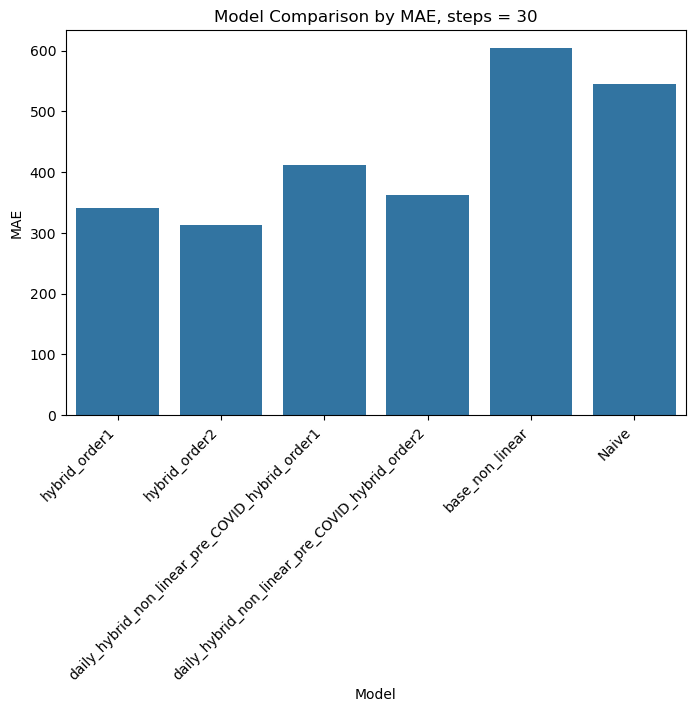

MAE Linear: 341.65 for step = 30, model = hybrid_order1
MAE Linear: 313.32 for step = 30, model = hybrid_order2
MAE Linear: 371.61 for step = 30, model = daily_hybrid_non_linear_incl_COVID_hybrid_order1
MAE Linear: 384.06 for step = 30, model = daily_hybrid_non_linear_incl_COVID_hybrid_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
Naive MAE: MAE = 545.37



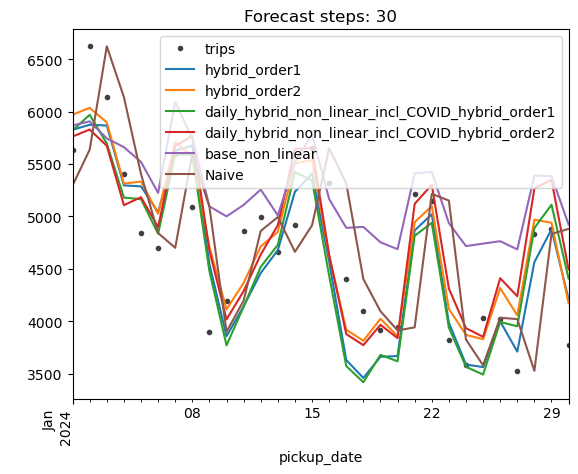

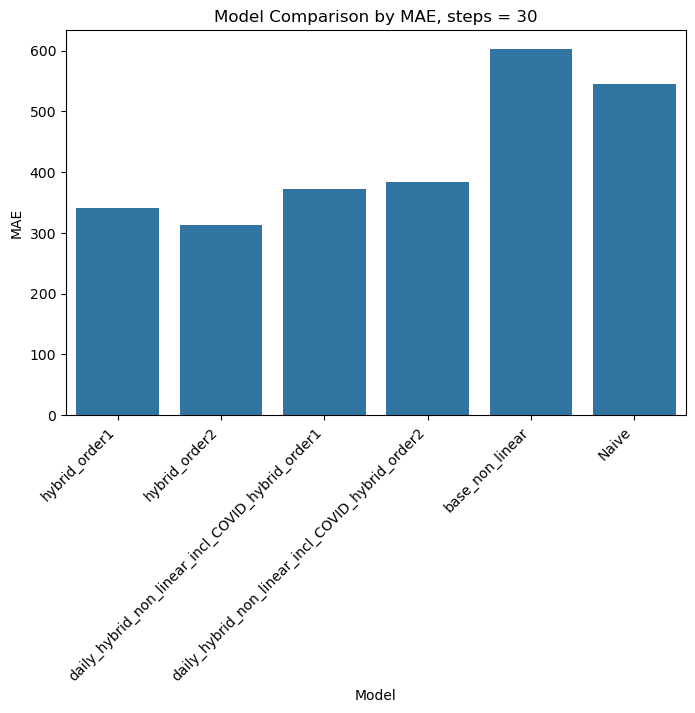

MAE Linear: 46.27 for step = 168, model = linear_order2
MAE Non Linear: 47.54 for step = 168, model = base_non_linear
MAE Non Linear: 48.49 for step = 168, model = hourly_non_linear_pre_COVID
Naive MAE: MAE = 59.89



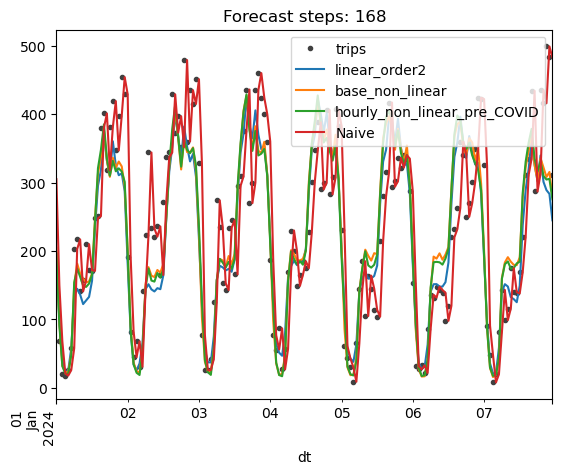

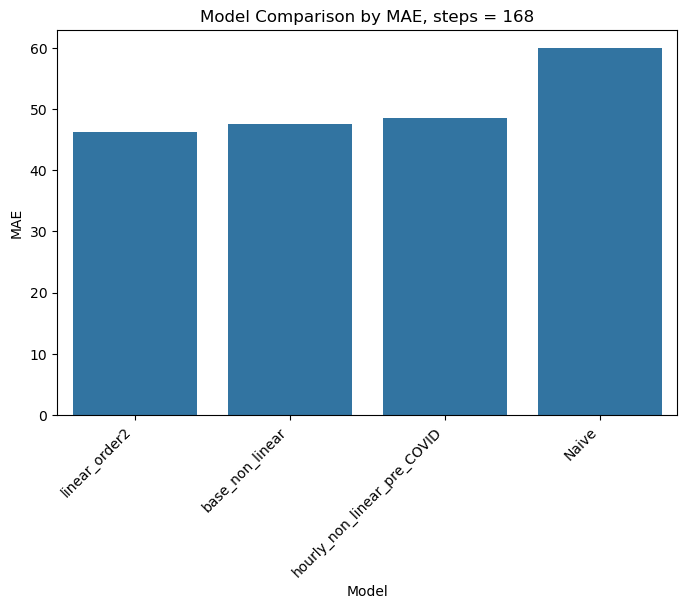

MAE Linear: 46.27 for step = 168, model = linear_order2
MAE Non Linear: 47.54 for step = 168, model = base_non_linear
MAE Non Linear: 49.63 for step = 168, model = hourly_non_linear_incl_COVID
Naive MAE: MAE = 59.89



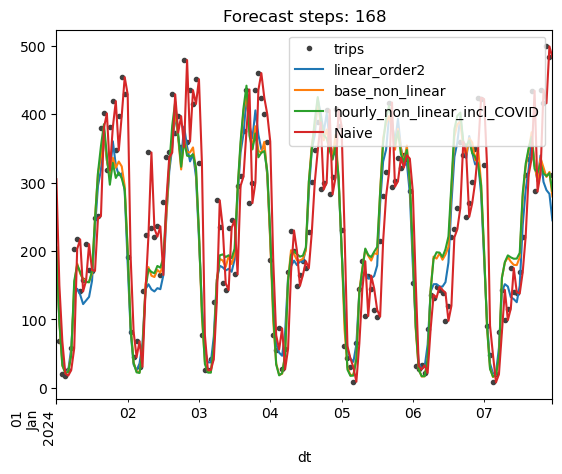

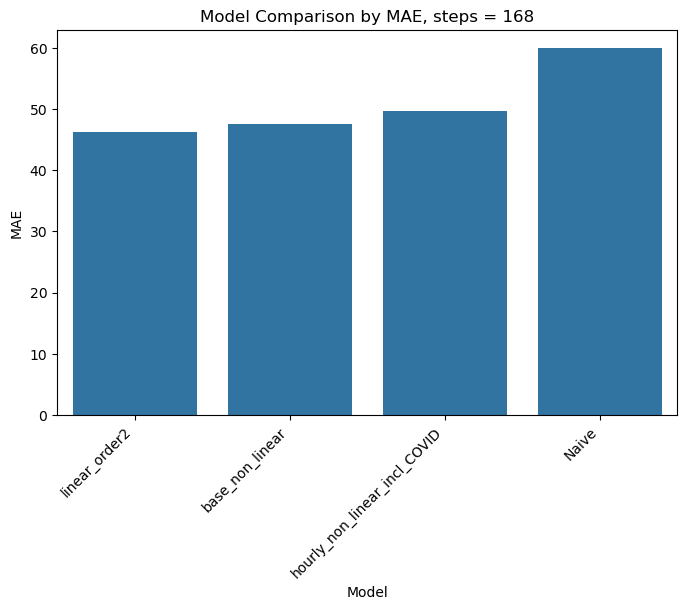

MAE Linear: 45.58 for step = 168, model = hybrid_order1
MAE Linear: 46.08 for step = 168, model = hybrid_order2
MAE Linear: 46.34 for step = 168, model = hourly_hybrid_non_linear_pre_COVID_hybrid_order1
MAE Linear: 45.94 for step = 168, model = hourly_hybrid_non_linear_pre_COVID_hybrid_order2
MAE Non Linear: 47.54 for step = 168, model = base_non_linear
Naive MAE: MAE = 59.89



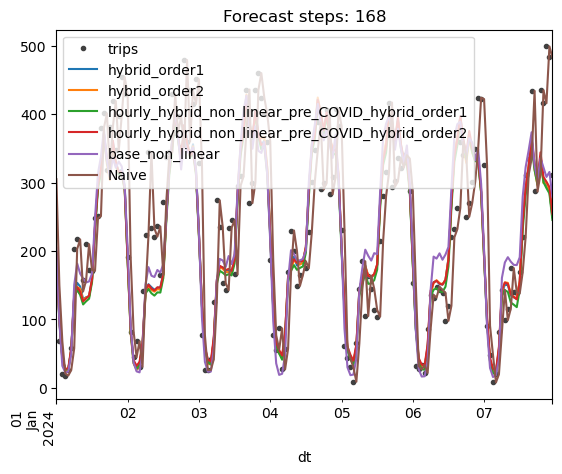

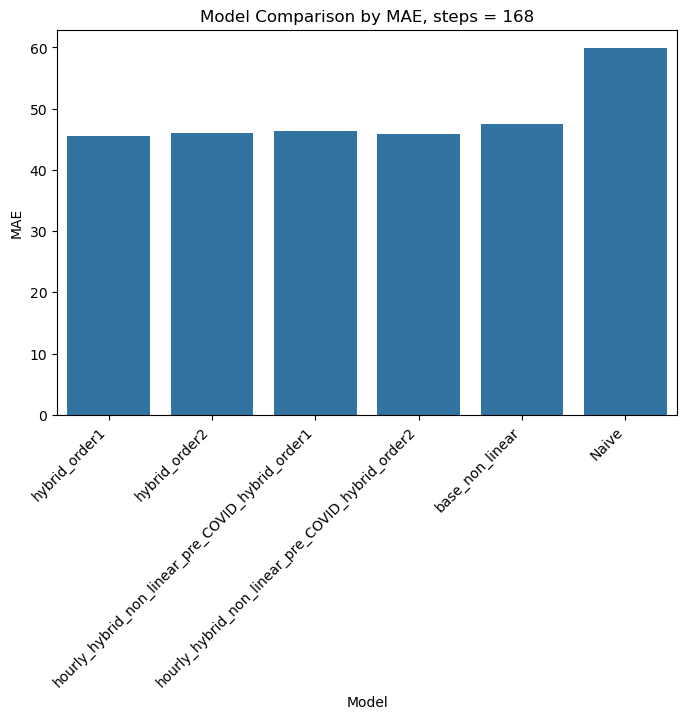

MAE Linear: 45.58 for step = 168, model = hybrid_order1
MAE Linear: 46.08 for step = 168, model = hybrid_order2
MAE Linear: 46.14 for step = 168, model = hourly_hybrid_non_linear_incl_COVID_hybrid_order1
MAE Linear: 46.64 for step = 168, model = hourly_hybrid_non_linear_incl_COVID_hybrid_order2
MAE Non Linear: 47.54 for step = 168, model = base_non_linear
Naive MAE: MAE = 59.89



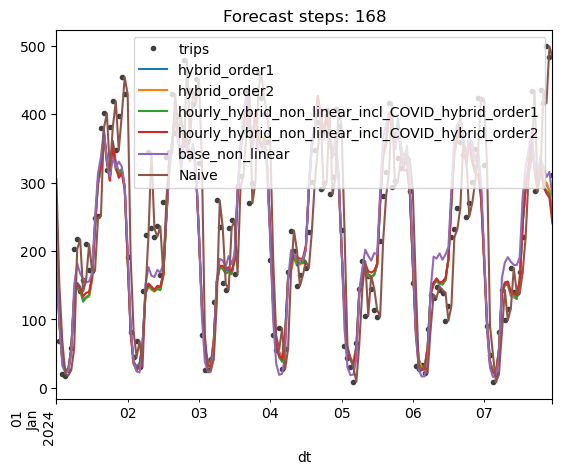

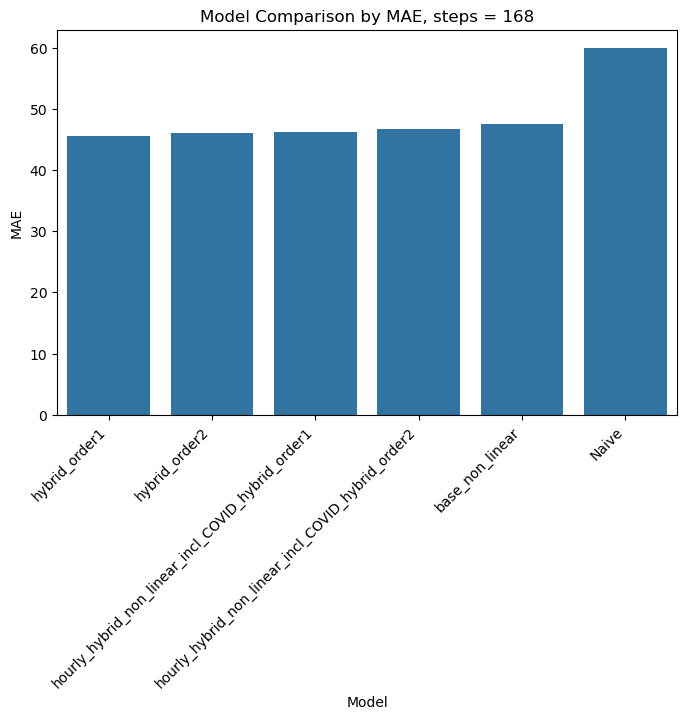

In [15]:
# Run test_hyperparams (if you are using the GPU make sure to restart the kernel first and skip the hyperparam tuning cell, otherwise XGBoost may run out of memory depending on your GPU)
test_hyperparams(dict_full, daily_lags, used_hourly_lags, ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test, daily_steps, hourly_steps)

## SHAP values

We now seek to explore the shap values of the models. We will first look at two example models one daily one hourly to get a feel for the SHAP values before we compute them all. 

In [16]:
import shap

In [ ]:
# Load linear design matrix for shap
linear_design_loaded, non_linear_design_loaded = load_design(config["model_sigs"]["daily_linear"])

# Load models
linear_models_loaded, non_linear_models_loaded = load_models(config["model_sigs"]["daily_linear"])

# Dictionary to store the shap values (it will contain tuples of shap values and design matricies)
shap_values_dict = {}

# Daily prefix
DAILY_PREFIX = config["shap"]["daily_prefix"]

# Hourly prefix 
HOURLY_PREFIX = config["shap"]["hourly_prefix"]

In [18]:
MODEL_PREFIX = config["model_naming"]["default_non_linear"]
X = non_linear_design_loaded[MODEL_PREFIX][0]
y = non_linear_design_loaded[MODEL_PREFIX][1]
dp = non_linear_design_loaded[MODEL_PREFIX][2]

model = non_linear_models_loaded[MODEL_PREFIX][0]

 99%|===================| 4317/4377 [01:09<00:00]        

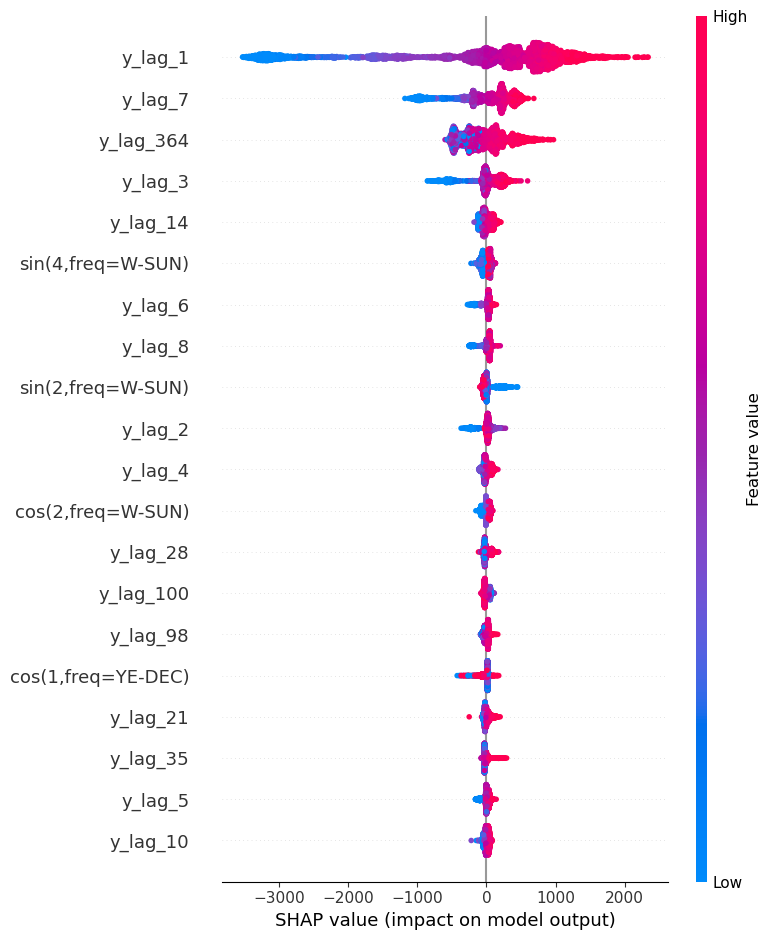

In [ ]:
# Compute SHAP values
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Store the values in the dict
shap_values_dict[f"{DAILY_PREFIX}_{MODEL_PREFIX}"] = (shap_values, X)

# Plot summary
shap.summary_plot(shap_values, X)

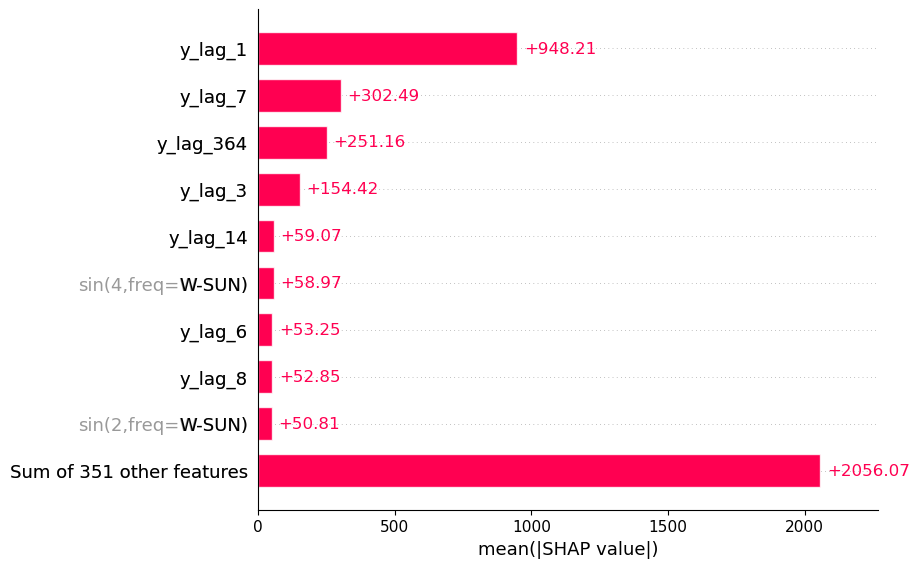

In [20]:
shap.plots.bar(shap_values)

As you can see in the above SHAP summary plot, lag_1 has the widest spread with low feature values causing low impact on model output and vice versa. It is interesting that lag_1 is the most significant feature by SHAP value as during testing I tried several different naive baselines, like lag of 1, lag of 7 etc etc and lag of 1 was consitently the best which is supported here by our SHAP values. 

Interestingly you also see that lag_7 and lag_365 have reasonably wide spreads again lining up with our EDA that there was both weekly and yearly seasonality in the taxi data. Now this is an XGBoost model so it is interesting that it has picked up on the lags rather than the fourier features when looking at seasonality. 

It's worth looking at a daily linear model to see if it favours the fourier features over the lags.

In [21]:
MODEL_PREFIX = config["model_naming"]["linear_model_prefix"] + "2"
X = linear_design_loaded[MODEL_PREFIX][0]
y = linear_design_loaded[MODEL_PREFIX][1]
dp = linear_design_loaded[MODEL_PREFIX][2]

model = linear_models_loaded[MODEL_PREFIX][0]

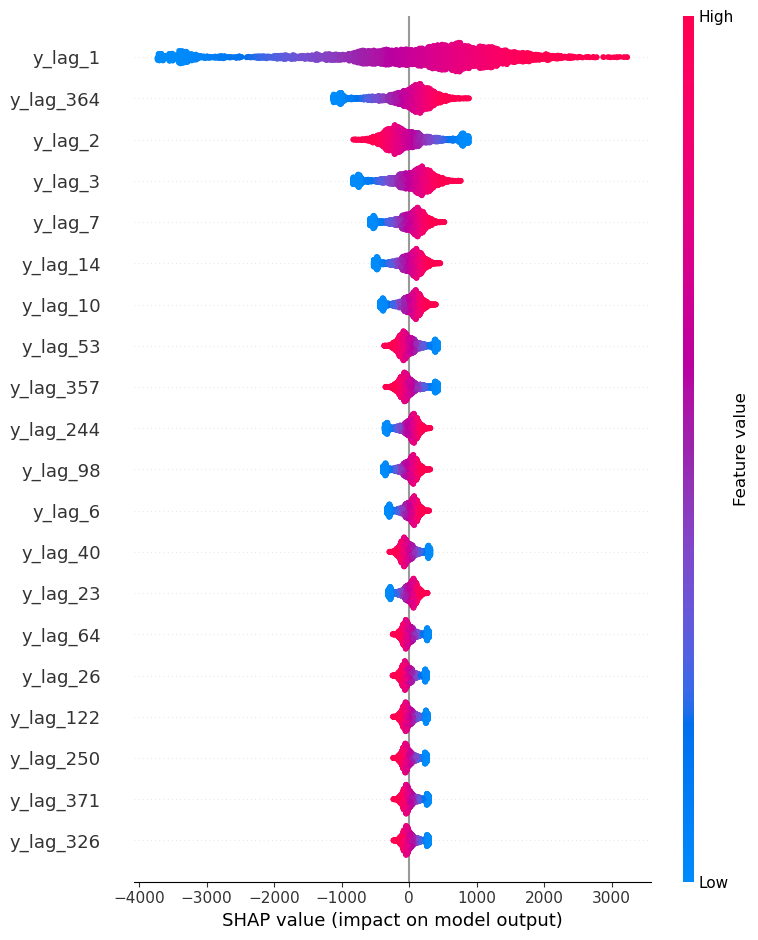

In [ ]:
# Compute SHAP values
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Store the values in the dict
shap_values_dict[f"{DAILY_PREFIX}_{MODEL_PREFIX}"] = (shap_values, X)

# Plot summary
shap.summary_plot(shap_values, X)

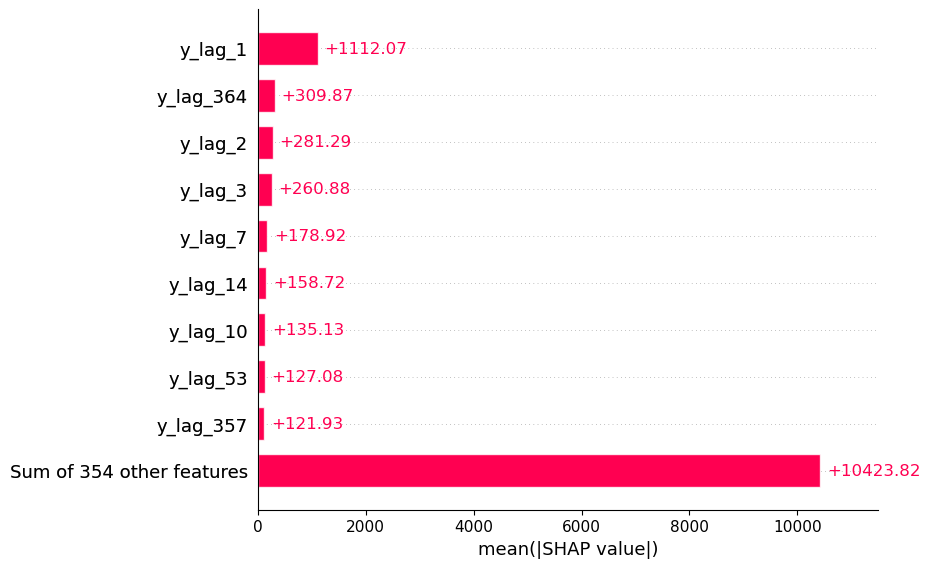

In [23]:
shap.plots.bar(shap_values)

The above is super interesting because it shows that our fourier features aren't at the top at all here. This goes against what I expected as I orignally thought that the linear regression would like the smooth fourier features that could allow it to capture things like annual seasonality. But it seems it has used the lags like lag_364 and lag_7 to capture the seasonality instead. 

This seems to be more of a memory property of the data, as in the value last year affects the value this year more than the yearly up and down of say slightly more taxis around the holidays (due to more flights). So lag features like lag 364 can better capture both the seasanolity of 1 year but also the year on year effects, like high values last year means high values this year is likely. 

There are a couple interesting things to note in terms of the shape on the summary plots. For example for lag 2 it seems high values 2 days ago cause a decrease in the model prediction and vice versa. But high values one day ago strongly suggest high values the next day. Lag 7 and lag 14 have high mean absolute shap values which is again are weekly seasonality. 

Finally it would be interesting to have an inital look at the SHAP values for the XGBoost component of the hybrid models, just to see what they are picking up. We will do this for hybrid_order2.

In [24]:
# Load linear design matrix for shap
linear_design_loaded, non_linear_design_loaded = load_design(config["model_sigs"]["daily_hybrid"])

# Load models
linear_models_loaded, non_linear_models_loaded = load_models(config["model_sigs"]["daily_hybrid"])

In [25]:
MODEL_PREFIX = config["model_naming"]["hybrid_model_prefix"] + "2"
X = linear_design_loaded[MODEL_PREFIX][0]
y = linear_design_loaded[MODEL_PREFIX][1]
dp = linear_design_loaded[MODEL_PREFIX][2]

model = linear_models_loaded[MODEL_PREFIX][2] # The XGBoost part

 99%|===================| 4350/4377 [01:01<00:00]        

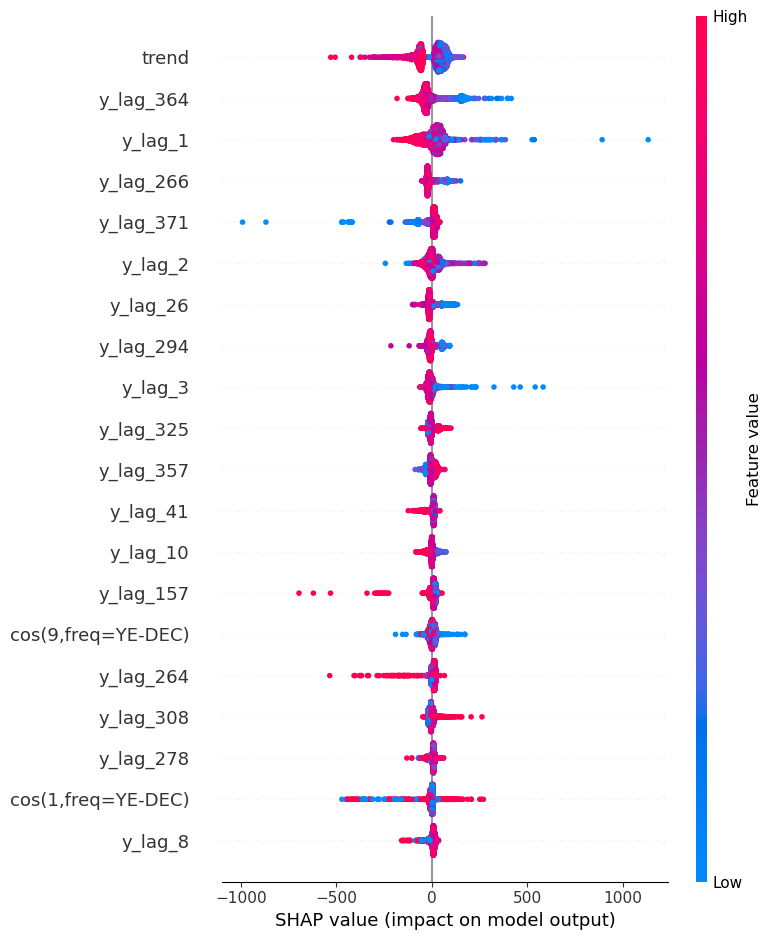

In [ ]:
# Compute SHAP values
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Store the values in the dict
shap_values_dict[f"{DAILY_PREFIX}_{MODEL_PREFIX}"] = (shap_values, X)

# Plot summary
shap.summary_plot(shap_values, X)

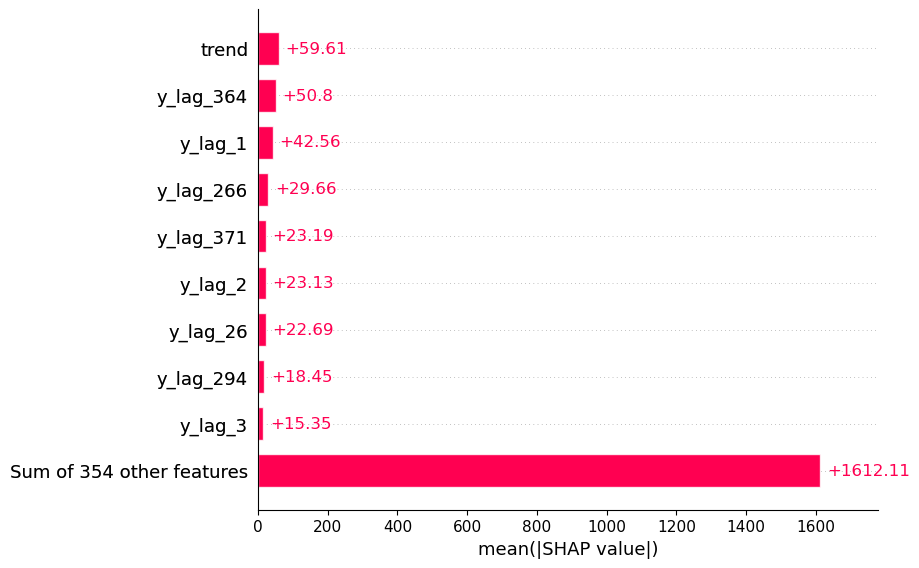

In [27]:
shap.plots.bar(shap_values)

The above is intersting. It would seem trend is the most important feature according to mean absolute SHAP value. There is a good actually a good plausible explanation for this. Notice that high values of trend cause a decrease in model predictions. Well if you look at the actual daily taxi data plotted you notice that since COVID (so high values for trend) the daily taxi count has decreased. So this is potentially what this XGBoost model is capturing that difference between pre and post COVID. You can see this again with the fact that it has marked the lag 364 as a negative predictor, so high values last year imply low values this year. This again is likely from that huge drop in taxi count from COVID as well as the general overall decline in yellow taxi usage that we see leading up to COVID due to the introduction of things like Green taxis + Uber from our EDA (although these are just intersting guesses).

It's also very clear that these effects are much smaller than that of the underlying model (hybrid_order2s linear component is the same as for linear_order2) with trend only having mean absoulute SHAP value of 59.61 compared to the linear components 1112.07 for y_lag_1.

We now do the same for the hourly models.



In [28]:
# Load linear design matrix for shap
linear_design_loaded, non_linear_design_loaded = load_design(config["model_sigs"]["hourly_linear"])

# Load models
linear_models_loaded, non_linear_models_loaded = load_models(config["model_sigs"]["hourly_linear"])

# Load hybrid models
hybrid_design_loaded, non_linear_design_loaded = load_design(config["model_sigs"]["hourly_hybrid"])
hybrid_models_loaded, non_linear_models_loaded = load_models(config["model_sigs"]["hourly_hybrid"])

In [29]:
MODEL_PREFIX_NON_LINEAR = config["model_naming"]["default_non_linear"]
X_non_linear = non_linear_design_loaded[MODEL_PREFIX_NON_LINEAR][0]
y = non_linear_design_loaded[MODEL_PREFIX_NON_LINEAR][1]
dp = non_linear_design_loaded[MODEL_PREFIX_NON_LINEAR][2]

MODEL_PREFIX_LINEAR = config["model_naming"]["linear_model_prefix"] + "2"
X_linear = linear_design_loaded[MODEL_PREFIX_LINEAR][0]
y_linear = linear_design_loaded[MODEL_PREFIX_LINEAR][1]
dp_linear = linear_design_loaded[MODEL_PREFIX_LINEAR][2]

model_linear = linear_models_loaded[MODEL_PREFIX_LINEAR][0]

model_non_linear = non_linear_models_loaded[MODEL_PREFIX_NON_LINEAR][0]

MODEL_PREFIX_HYBRID = config["model_naming"]["hybrid_model_prefix"] + "2"
X_hybrid = hybrid_design_loaded[MODEL_PREFIX_HYBRID][0]
y_hybrid = hybrid_design_loaded[MODEL_PREFIX_HYBRID][1]
dp_hybrid = hybrid_design_loaded[MODEL_PREFIX_HYBRID][2]

model_hybrid = hybrid_models_loaded[MODEL_PREFIX_HYBRID][2]

100%|===================| 105136/105168 [27:55<00:00]        

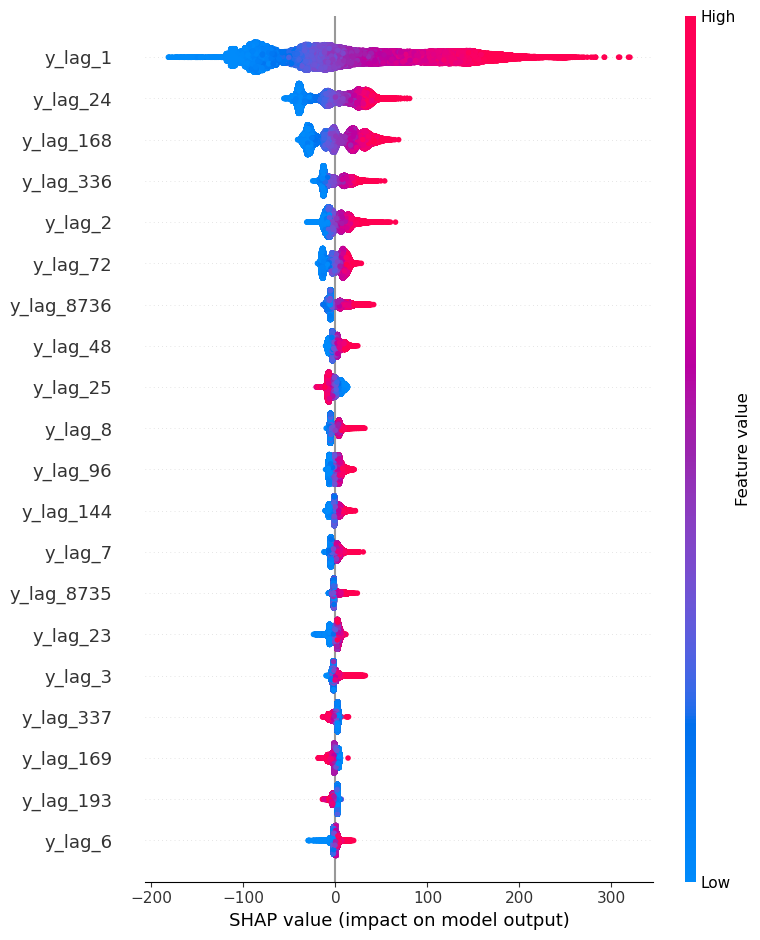

In [ ]:
# Compute SHAP values
explainer = shap.Explainer(model_non_linear, X_non_linear)
shap_values = explainer(X_non_linear)

# Store the values in the dict
shap_values_dict[f"{HOURLY_PREFIX}_{MODEL_PREFIX_NON_LINEAR}"] = (shap_values, X_non_linear)

# Plot summary
shap.summary_plot(shap_values, X_non_linear)

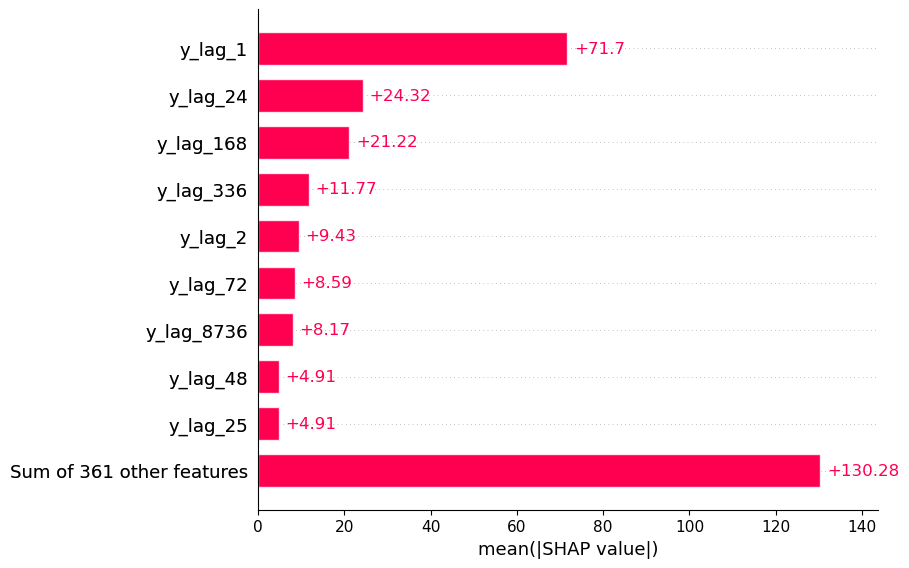

In [31]:
shap.plots.bar(shap_values)

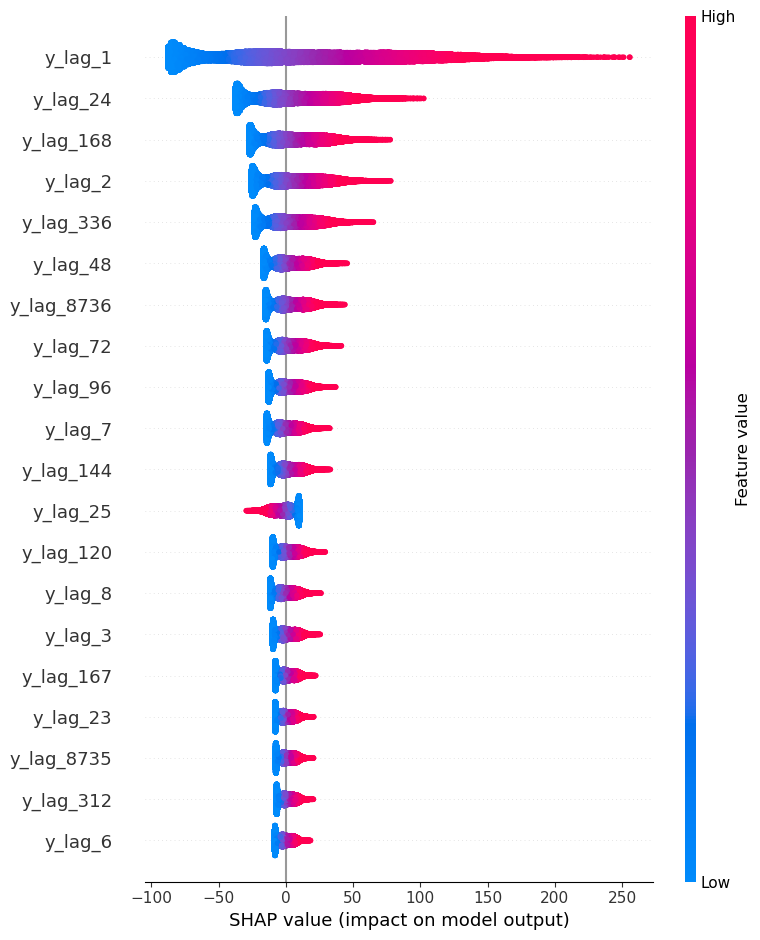

In [ ]:
# Compute SHAP values
explainer = shap.Explainer(model_linear, X_linear)
shap_values = explainer(X_linear)

# Store the values in the dict
shap_values_dict[f"{HOURLY_PREFIX}_{MODEL_PREFIX_LINEAR}"] = (shap_values, X_linear)

# Plot summary
shap.summary_plot(shap_values, X_linear)

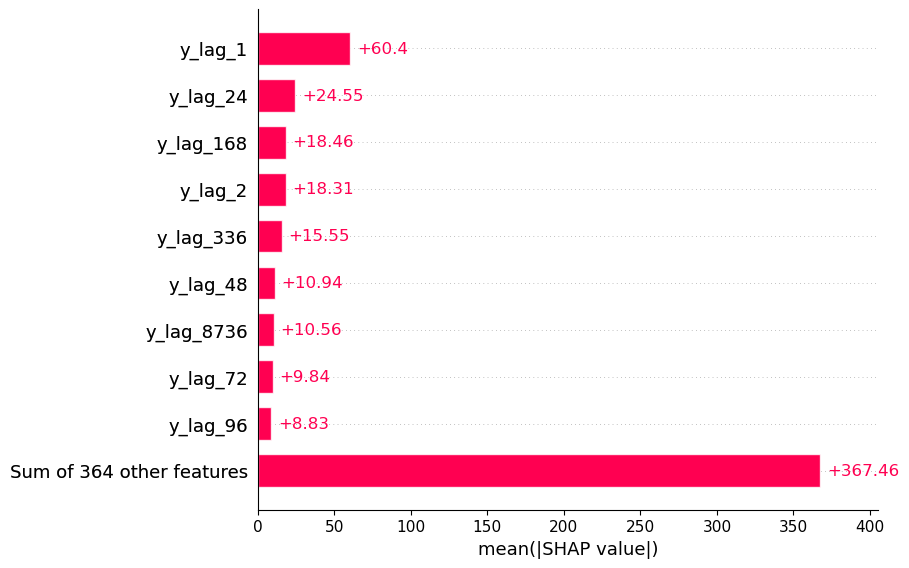

In [33]:
shap.plots.bar(shap_values)

100%|===================| 105127/105168 [23:01<00:00]        

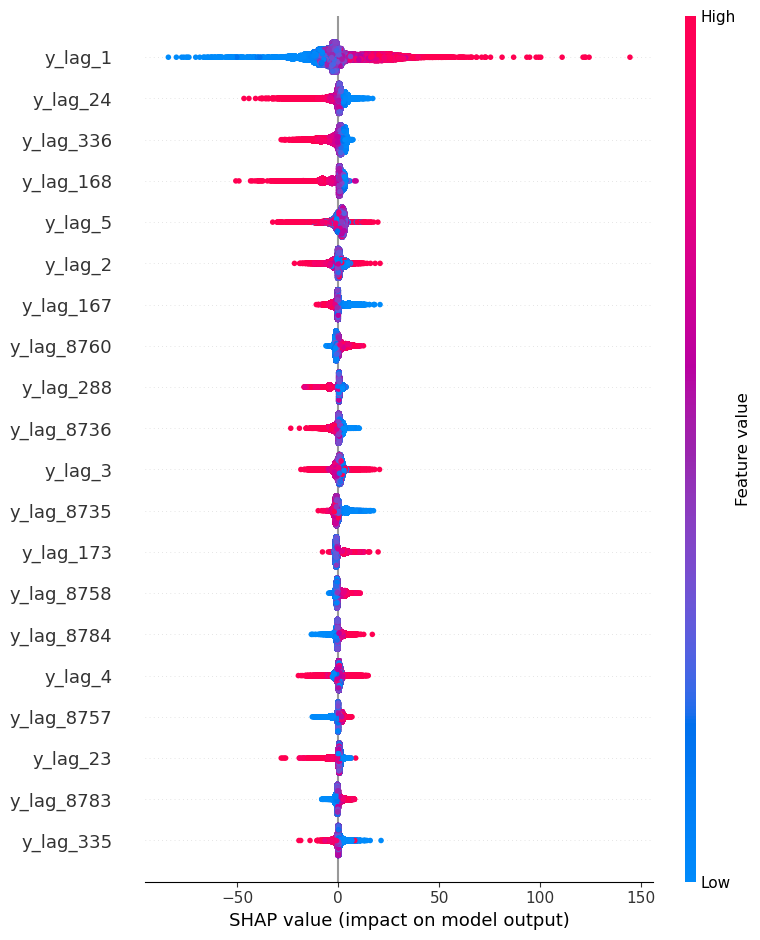

In [ ]:
# Compute SHAP values
explainer = shap.Explainer(model_hybrid, X_hybrid)
shap_values = explainer(X_hybrid)

# Store the values in the dict
shap_values_dict[f"{HOURLY_PREFIX}_{MODEL_PREFIX_HYBRID}"] = (shap_values, X_hybrid)

# Plot summary
shap.summary_plot(shap_values, X_hybrid)


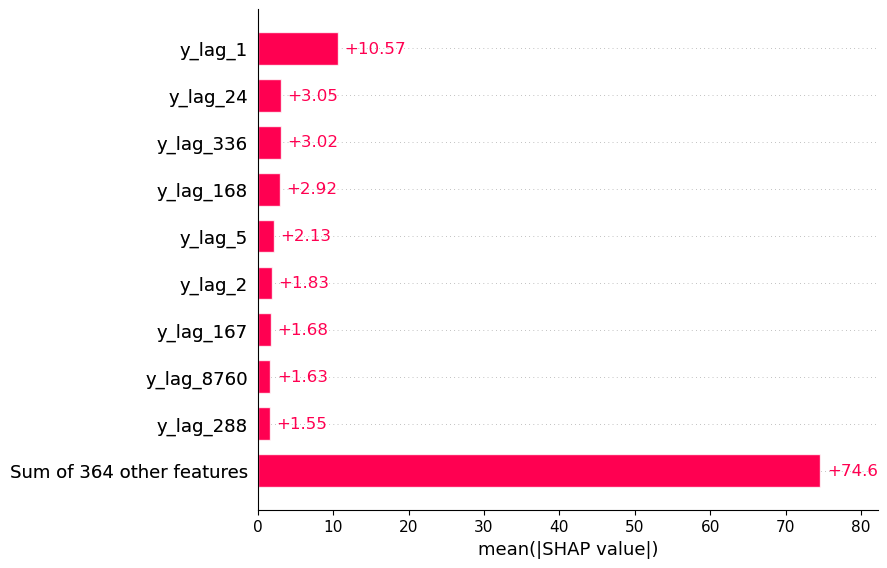

In [35]:
shap.plots.bar(shap_values)

What we immediately observe is we have the same pattern from the daily models. The daily and weekly seasonality (24 and 168 hours) both appear as lags rather than as their respective fourier features. We also see that once again lag 1 is the most important feature (by mean abs SHAP value) to both the linear and non linear models. 

We also see that the lag of 336 (168 * 2) also has high importance which again supports the idea that the lags are picking up the seasonality perhaps better than the fourier features. 

We further see that lag 8736 is significant in all three models, this is our yearly seasonality in the data. Although not flagged in the EDA (potentially because we tried 8760 for exactly one year, although this does show up in the hybrid). If you read config.yml you can see we included some additional significant lags around 8760 and 4380 to try and capture any potentially half or annual seasonlaity with the lags. We observe at least in the inital top 20 we can't see any half annual seasonality. But can see the annual lags.

What we would now like to do is select the top 30 features by mean absoulute SHAP value and retrain the models, to see if they caputre most of the signal. 



In [42]:
mean_abs_shap = np.abs(shap_values.values).mean(axis = 0)

feature_names = X_hybrid.columns


In [43]:
# Get indices of top 30 features (by mean abs SHAP value)
top_indices = np.argsort(mean_abs_shap)[-30:][::-1]

top_features = [(feature_names[i], mean_abs_shap[i]) for i in top_indices]


In [45]:
top_features

[('y_lag_1', np.float64(10.569901174167345)),
 ('y_lag_24', np.float64(3.0503487110551073)),
 ('y_lag_336', np.float64(3.0235670614810966)),
 ('y_lag_168', np.float64(2.9175911738293117)),
 ('y_lag_5', np.float64(2.1307042771681055)),
 ('y_lag_2', np.float64(1.8324497575077585)),
 ('y_lag_167', np.float64(1.6825842501422206)),
 ('y_lag_8760', np.float64(1.6323602356652358)),
 ('y_lag_288', np.float64(1.547124488881026)),
 ('y_lag_8736', np.float64(1.4907036262603517)),
 ('y_lag_3', np.float64(1.4682607335898794)),
 ('y_lag_8735', np.float64(1.4525824026273717)),
 ('y_lag_173', np.float64(1.4501812496887314)),
 ('y_lag_8758', np.float64(1.4447557852154547)),
 ('y_lag_8784', np.float64(1.244861507008638)),
 ('y_lag_4', np.float64(1.1790378988974235)),
 ('y_lag_8757', np.float64(1.1734803849600564)),
 ('y_lag_23', np.float64(1.146934931678694)),
 ('y_lag_8783', np.float64(1.0863622743335488)),
 ('y_lag_335', np.float64(1.0017773544840405)),
 ('y_lag_7', np.float64(0.9939766138244389)),
 (

In [50]:
type(feature_names)
import pandas as pd

In [52]:
type(top_features)

list

In [51]:
isinstance(feature_names, pd.Index)

True